# Budgeted MLMC vs MLQMC for the Analytic Function 

## Imports

In [1]:
import mlqmcpy as mp
from mlqmcpy.problems.analytic import analytic

In [2]:
import numpy as np
import scipy.stats
import qmcpy as qp
import os

In [3]:
import torch 
torch.set_default_dtype(torch.float64)

In [4]:
import matplotlib 
from matplotlib import pyplot
pyplot.style.use("seaborn-v0_8-whitegrid")
COLORS = ['xkcd:purple', 'xkcd:green', 'xkcd:blue', 'xkcd:red', 'xkcd:turquoise', 'xkcd:pink', 'xkcd:brown', 'xkcd:light blue', 'xkcd:teal', 'xkcd:orange']
pyplot.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=COLORS)
WIDTH = 2*(500/72)
LW = 3
alpha = .2

## Experiment

In [5]:
force_experiment = False
datafile = "budgeted_comparison_analytic.data.big.npy"
if not os.path.isfile(datafile) or force_experiment:
    # parameters 
    dimension = 2
    num_levels = 4
    initial_sample_size = 2**(num_levels-np.arange(num_levels)+2)
    max_budgets = 2**np.arange(6,16)
    trials = 25
    zip_IteratorClass_DiscreteDistribClass = [
        #(mp.GreedyMLQMCIterator,qp.Lattice,"R-MLQMC Lattice"),
        (mp.GreedyMLQMCIterator,qp.DigitalNetB2,"R-MLQMC DNet"),
        #(mp.GreedyFastGaussianProcessMLQMCIterator,qp.Lattice,"IGP-MLQMC Lattice"),
        (mp.GreedyFastGaussianProcessMLQMCIterator,qp.DigitalNetB2,"IGP-MLQMC DNet"),
        #(mp.FastMultiTaskGaussianProcessMLQMCIterator,qp.Lattice,"MTGP-MLQMC Lattice"),
        (mp.FastMultiTaskGaussianProcessMLQMCIterator,qp.DigitalNetB2,"MTGP-MLQMC DNet"),
    ]
    # experiment
    names = [name for (IteratorClass,DiscreteDistribClass,name) in zip_IteratorClass_DiscreteDistribClass]
    true_solution = analytic.exact.Q.mean(level=num_levels-1)
    cost_per_level = 2.**(np.arange(num_levels)-num_levels+1) # Rescale so that finest level has unit cost
    print("max_budgets: %s"%max_budgets)
    print("cost_per_level: %s"%str(cost_per_level))
    print("initial_sample_size: %s"%str(initial_sample_size))
    print("initial cost: %.1f"%(cost_per_level*initial_sample_size).sum())
    print()
    costs = np.empty((len(zip_IteratorClass_DiscreteDistribClass),len(max_budgets),trials))
    means = np.empty((len(zip_IteratorClass_DiscreteDistribClass),len(max_budgets),trials))
    std_errors = np.empty((len(zip_IteratorClass_DiscreteDistribClass),len(max_budgets),trials))
    true_errors = np.empty((len(zip_IteratorClass_DiscreteDistribClass),len(max_budgets),trials))
    for i,(IteratorClass,DiscreteDistribClass,name) in enumerate(zip_IteratorClass_DiscreteDistribClass):
        print("%s"%name)
        for j in range(len(max_budgets)):
            max_budget = max_budgets[j]
            print("\tbudget = %d"%max_budget)
            for t in range(trials):
                iterator = IteratorClass(
                    dimension,
                    initial_sample_size=initial_sample_size,
                    cost_per_level=cost_per_level,
                    max_budget = max_budget,
                    discrete_distribution_type = DiscreteDistribClass)
                problem = analytic if isinstance(iterator,mp.FastMultiTaskGaussianProcessMLQMCIterator) else analytic.ml
                problem_tf = (lambda level,x: problem(level,1-2*np.abs(x-1/2))) if DiscreteDistribClass==qp.Lattice else problem
                for iter, new_samples in enumerate(iterator):
                    new_results = {level: problem_tf(level,samples) for level,samples in new_samples.items()}
                    iterator.update(new_results)
                costs[i,j,t] = iterator.cost
                means[i,j,t] = iterator.mean
                std_errors[i,j,t] = iterator.standard_error
                true_errors[i,j,t] = np.abs(true_solution-means[i,j,t])
                print("\t\ttrial: %-6d iteration: %-6d cost: %-10d mean: %-15.3e std error: %-15.3e true error: %-15.3e"%\
                    (t,iter,costs[i,j,t],means[i,j,t],std_errors[i,j,t],true_errors[i,j,t]))
        print()
    data = {
        "dimension": dimension,
        "num_levels": num_levels,
        "initial_sample_size": initial_sample_size,
        "max_budgets": max_budgets,
        "names": names,
        "costs": costs,
        "means": means,
        "std_errors": std_errors,
        "true_errors": true_errors,
    }
    np.save(datafile,data)
else:
    data = np.load(datafile,allow_pickle=True)[()]
    dimension = data["dimension"]
    num_levels = data["num_levels"]
    initial_sample_size = data["initial_sample_size"]
    max_budgets = data["max_budgets"]
    names = data["names"]
    costs = data["costs"]
    means = data["means"]
    std_errors = data["std_errors"]
    true_errors = data["true_errors"]
    trials = costs.shape[-1]

max_budgets: [   64   128   256   512  1024  2048  4096  8192 16384 32768]
cost_per_level: [0.125 0.25  0.5   1.   ]
initial_sample_size: [64 32 16  8]
initial cost: 32.0

R-MLQMC DNet
	budget = 64
		trial: 0      iteration: 0      cost: 256        mean: 5.165e-01       std error: 4.578e-04       true error: 6.836e-04      
		trial: 1      iteration: 0      cost: 256        mean: 5.173e-01       std error: 5.152e-04       true error: 1.142e-04      
		trial: 2      iteration: 0      cost: 256        mean: 5.157e-01       std error: 7.726e-04       true error: 1.420e-03      
		trial: 3      iteration: 0      cost: 256        mean: 5.184e-01       std error: 5.994e-04       true error: 1.215e-03      
		trial: 4      iteration: 0      cost: 256        mean: 5.177e-01       std error: 7.766e-04       true error: 5.464e-04      
		trial: 5      iteration: 0      cost: 256        mean: 5.164e-01       std error: 4.756e-04       true error: 7.109e-04      
		trial: 6      iteration: 0      

## Analysis

above 0 means it is over budget, below 0 means it is within the budget
as only the FastMultiTaskGaussianProcessMLQMCIterator stays within budget, the rest of the notebook should be taken with a grain of salt


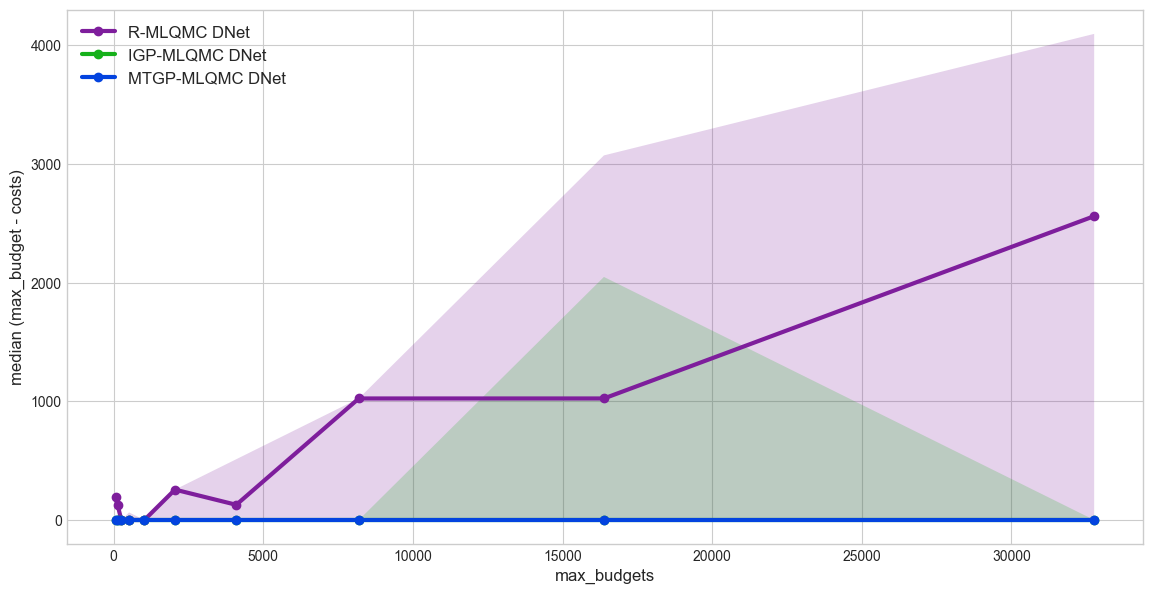

In [6]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(WIDTH,WIDTH/2))
for i,name in enumerate(names):
    vals = costs[i]-max_budgets[:,None]
    q_low = np.nanquantile(vals,.25,axis=1)
    q_med = np.nanquantile(vals,.5,axis=1)
    q_high = np.nanquantile(vals,.75,axis=1)
    ax.plot(max_budgets,q_med,'-o',label=name,linewidth=LW)
    ax.fill_between(max_budgets,q_low,q_high,alpha=alpha)
ax.legend(frameon=False,fontsize="large")
ax.set_xlabel("max_budgets",fontsize="large")
ax.set_ylabel("median (max_budget - costs)",fontsize="large");
print("above 0 means it is over budget, below 0 means it is within the budget")
print("as only the FastMultiTaskGaussianProcessMLQMCIterator stays within budget, the rest of the notebook should be taken with a grain of salt")

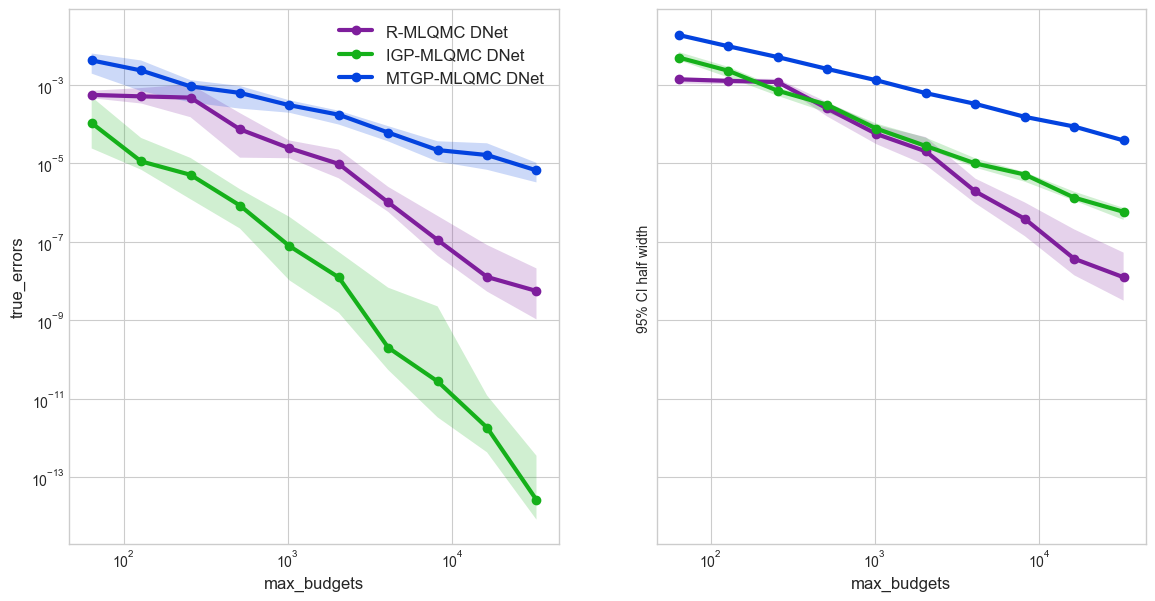

In [7]:
confidence = .95
beta = scipy.stats.norm.ppf(1-(1-confidence)/2)
fig,ax = pyplot.subplots(nrows=1,ncols=2,figsize=(WIDTH,WIDTH/2),sharey=True,sharex=True)
for i,name in enumerate(names):
    for j,vals in enumerate([true_errors[i],beta*std_errors[i]]):
        q_low = np.nanquantile(vals,.25,axis=1)
        q_med = np.nanquantile(vals,.5,axis=1)
        q_high = np.nanquantile(vals,.75,axis=1)
        ax[j].plot(max_budgets,q_med,'-o',label=name,linewidth=LW)
        #ax[j].scatter(costs[i],vals,color=COLORS[i])
        ax[j].fill_between(max_budgets,q_low,q_high,alpha=alpha)
ax[0].legend(frameon=False,fontsize="large")
ax[0].set_yscale("log",base=10)
ax[0].set_xscale("log",base=10)
ax[0].set_ylabel("true_errors",fontsize="large")
ax[1].set_ylabel("%d%% CI half width "%int(100*confidence))
for j in range(2):
    ax[j].set_xlabel("max_budgets",fontsize="large")

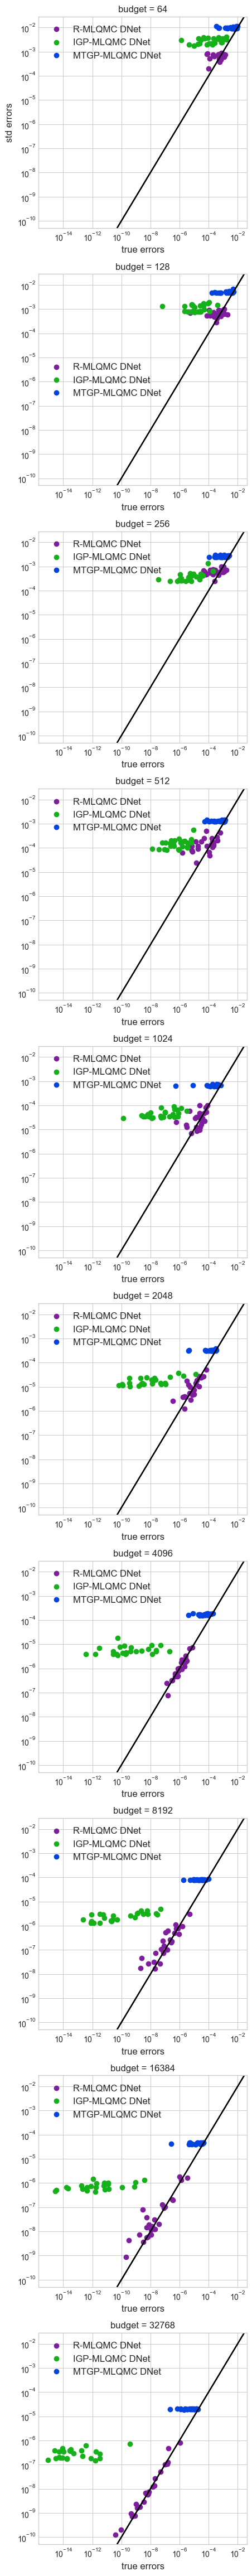

In [8]:
fig,ax = pyplot.subplots(nrows=len(max_budgets),ncols=1,figsize=(WIDTH/3,WIDTH*len(max_budgets)/3),sharex=True,sharey=True)
for i,name in enumerate(names):
    for j in range(len(max_budgets)):
        ax[j].scatter(true_errors[i,j],std_errors[i,j],label=name)
        ax[j].axline(xy1=(0,0),slope=1,color="k")
ax[0].set_xscale("log",base=10)
ax[0].set_yscale("log",base=10)
ax[0].set_ylabel("std errors",fontsize="large")
for j in range(len(max_budgets)):
    ax[j].legend(frameon=False,fontsize="large")#,ncols=len(max_budgets),bbox_to_anchor=(10,-.25))
    ax[j].set_xlabel("true errors",fontsize="large")
    ax[j].set_title("budget = %d"%max_budgets[j])
    ax[j].xaxis.set_tick_params(labelbottom=True)
fig.tight_layout()